In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dimensiones originales: (25000, 4)
Columnas originales: ['weather_condition', 'distance_km', 'delivery_time_hours', 'time_diff_bin']
Eliminada columna 'time_diff_bin'

Columnas después de crear dummies:
['distance_km', 'clima_clear', 'clima_cold', 'clima_foggy', 'clima_hot', 'clima_rainy', 'clima_stormy']

Train size: 17500, Test size: 7500

EVALUACIÓN DEL MODELO (Regresión Lineal con Dummies de Clima)
Métrica              Train        Test        
--------------------------------------------
RMSE (horas)         1.62         1.62        
R²                   0.7356       0.7353      
MAE (horas)          1.28         1.28        

COEFICIENTES POR CLIMA
Intercepto base: 2.4663
Pendiente común (h/km): 0.0250

Clear        -> Intercepto: 0.9939 horas
Cold         -> Intercepto: 0.9876 horas
Foggy        -> Intercepto: 2.7111 horas
Hot          -> Intercepto: 0.9984 horas
Rainy        -> Intercepto: 4.0491 horas
Stormy       -> Intercepto: 5.0578 horas


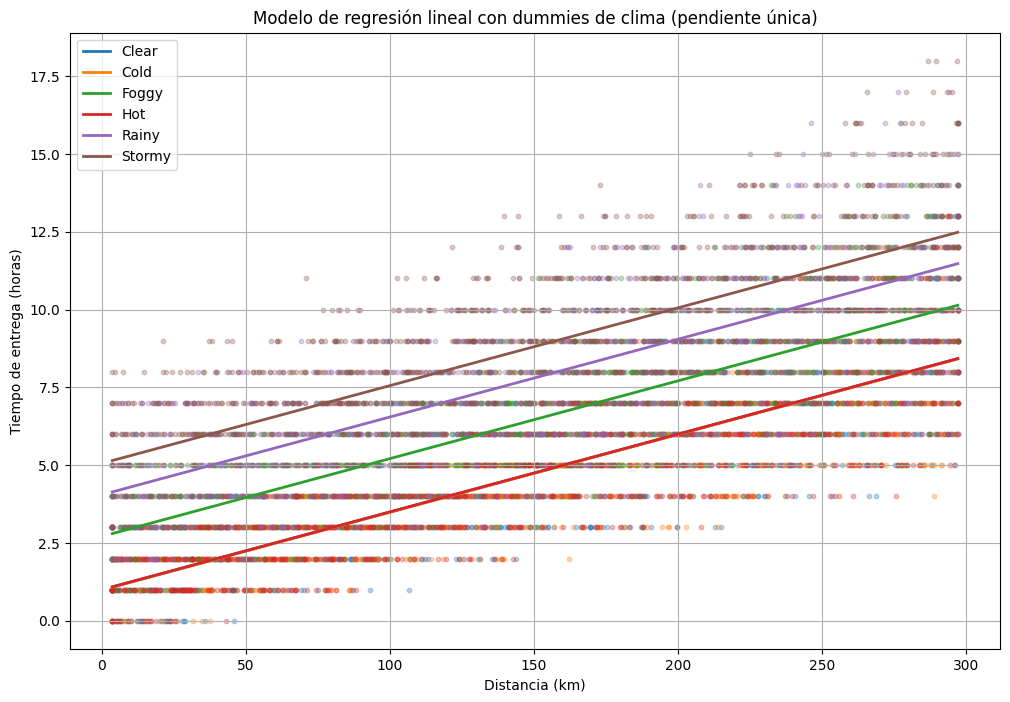

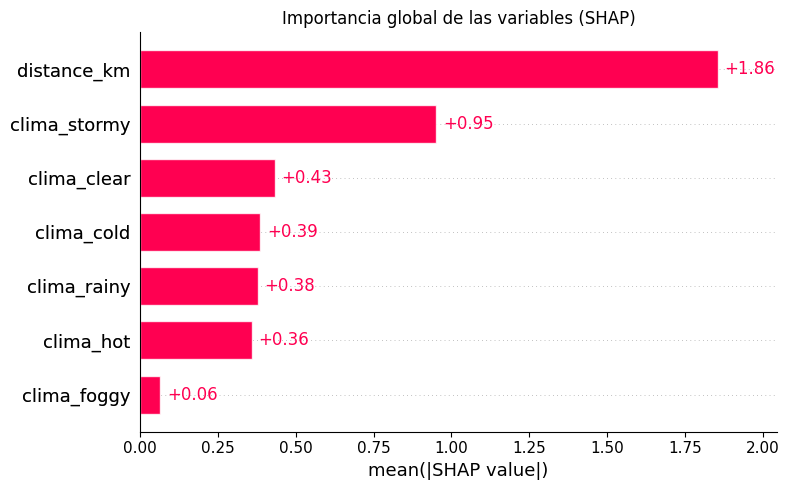

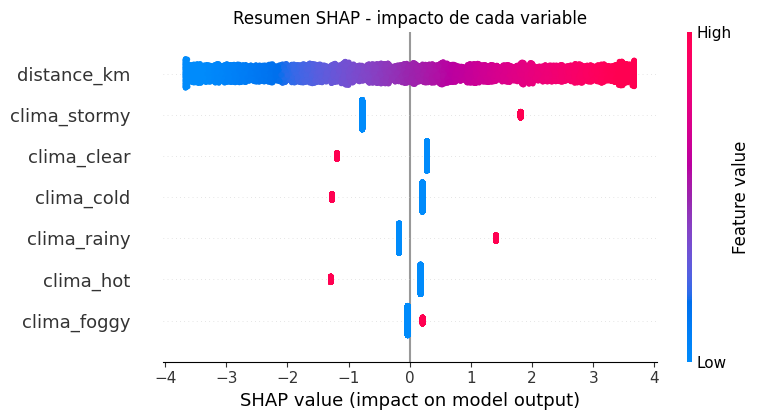


Variable más importante según SHAP: distance_km


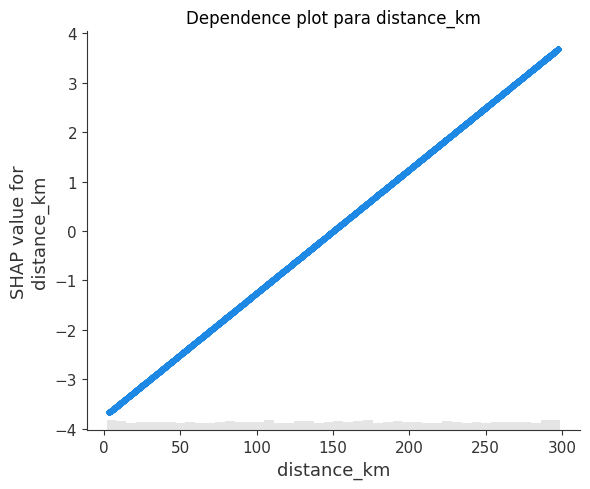

In [26]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import shap


# ============================================================================
# 1. CARGAR DATOS
# ============================================================================
df = pd.read_csv('/content/drive/MyDrive/DATA 2025 /Trabajo final /nuevoM_df.csv')
print("Dimensiones originales:", df.shape)
print("Columnas originales:", list(df.columns))

# Eliminar columna no deseada si existe
if 'time_diff_bin' in df.columns:
    df = df.drop(columns=['time_diff_bin'])
    print("Eliminada columna 'time_diff_bin'")

# Asegurar que weather_condition sea string
df['weather_condition'] = df['weather_condition'].astype(str)

# ============================================================================
# 2. CREAR VARIABLES DUMMY (SIN INTERACCIONES)
# ============================================================================
weather_dummies = pd.get_dummies(df['weather_condition'], prefix='clima', drop_first=False)
df = pd.concat([df, weather_dummies], axis=1)
df = df.drop(columns=['weather_condition'])   # ya no necesitamos la original

# Ahora las columnas predictoras son: distance_km + las dummies de clima
print("\nColumnas después de crear dummies:")
print([c for c in df.columns if c != 'delivery_time_hours'])

# ============================================================================
# 3. SEPARAR PREDICTORES Y OBJETIVO
# ============================================================================
target = 'delivery_time_hours'
X = df.drop(columns=[target])
y = df[target]

# ============================================================================
# 4. DIVIDIR EN TRAIN Y TEST
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# ============================================================================
# 5. ENTRENAR MODELO DE REGRESIÓN LINEAL CON DUMMIES (SIN INTERACCIONES)
# ============================================================================
model = LinearRegression()
model.fit(X_train, y_train)

# ============================================================================
# 6. EVALUACIÓN
# ============================================================================
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*50)
print("EVALUACIÓN DEL MODELO (Regresión Lineal con Dummies de Clima)")
print("="*50)
print(f"{'Métrica':<20} {'Train':<12} {'Test':<12}")
print("-"*44)
print(f"{'RMSE (horas)':<20} {rmse_train:<12.2f} {rmse_test:<12.2f}")
print(f"{'R²':<20} {r2_train:<12.4f} {r2_test:<12.4f}")
print(f"{'MAE (horas)':<20} {mae_train:<12.2f} {mae_test:<12.2f}")

# ============================================================================
# 7. INTERPRETACIÓN DE COEFICIENTES: INTERCEPTOS POR CLIMA
# ============================================================================
# El modelo tiene la forma:
# tiempo = intercepto_base + coef_dist * distance_km + suma(coef_dummy_c * dummy_c)
# Para un clima c, el intercepto total = intercepto_base + coef_dummy_c

intercepto_base = model.intercept_
coef_dist = model.coef_[X.columns.get_loc('distance_km')]

print("\n" + "="*50)
print("COEFICIENTES POR CLIMA")
print("="*50)
print(f"Intercepto base: {intercepto_base:.4f}")
print(f"Pendiente común (h/km): {coef_dist:.4f}\n")

# Lista de columnas dummy (todas las que empiezan con 'clima_')
dummy_cols = [c for c in X.columns if c.startswith('clima_')]
for dummy in dummy_cols:
    coef_dummy = model.coef_[X.columns.get_loc(dummy)]
    intercepto_clima = intercepto_base + coef_dummy
    clima_nombre = dummy.replace('clima_', '').capitalize()
    print(f"{clima_nombre:<12} -> Intercepto: {intercepto_clima:.4f} horas")

# ============================================================================
# 8. VISUALIZACIÓN: RECTAS PARALELAS POR CLIMA
# ============================================================================
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10.colors

# Rango de distancias para dibujar las rectas
dist_range = np.linspace(X_test['distance_km'].min(), X_test['distance_km'].max(), 100)

for i, dummy in enumerate(dummy_cols):
    clima_nombre = dummy.replace('clima_', '').capitalize()
    # Calcular la predicción para ese clima (dummy=1, las demás=0)
    pred = intercepto_base + coef_dist * dist_range
    # Añadir el efecto de la dummy (solo si dummy=1)
    coef_dummy = model.coef_[X.columns.get_loc(dummy)]
    pred += coef_dummy   # porque la dummy es 1
    plt.plot(dist_range, pred, color=colors[i % len(colors)],
             label=clima_nombre, linewidth=2)

    # Mostrar puntos reales de ese clima en test
    mask = X_test[dummy] == 1
    if mask.any():
        plt.scatter(X_test.loc[mask, 'distance_km'], y_test[mask],
                    color=colors[i % len(colors)], alpha=0.3, s=10)

plt.xlabel('Distancia (km)')
plt.ylabel('Tiempo de entrega (horas)')
plt.title('Modelo de regresión lineal con dummies de clima (pendiente única)')
plt.legend()
plt.grid(True)
plt.show()



# ============================================================================
# 9. ANÁLISIS SHAP CON NUEVA API
# ============================================================================
import shap

# Asegurar que todos los datos sean float (evita problemas de tipos)
X_train_float = X_train.astype(float)
X_test_float = X_test.astype(float)

# Usar el explainer automático (detecta que es modelo lineal)
explainer = shap.Explainer(model, X_train_float)
shap_values = explainer(X_test_float)

# 1. Importancia global (bar plot)
shap.plots.bar(shap_values, show=False)
plt.title("Importancia global de las variables (SHAP)")
plt.tight_layout()
plt.show()

# 2. Resumen (beeswarm)
shap.plots.beeswarm(shap_values, show=False)
plt.title("Resumen SHAP - impacto de cada variable")
plt.tight_layout()
plt.show()

# 3. Dependence plot para la variable más importante
# Obtener la variable con mayor importancia absoluta media
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
most_important_idx = np.argmax(mean_abs_shap)
most_important_var = X_test_float.columns[most_important_idx]
print(f"\nVariable más importante según SHAP: {most_important_var}")

# Dependence plot
shap.plots.scatter(shap_values[:, most_important_idx], show=False)
plt.title(f"Dependence plot para {most_important_var}")
plt.tight_layout()
plt.show()